In [2]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, auc, roc_curve

In [3]:
DATA_PATH = Path.cwd().parent / "data" / "interim"

X_train = joblib.load(DATA_PATH / "X_train.pkl")
y_train = joblib.load(DATA_PATH / "y_train.pkl")
X_test = joblib.load(DATA_PATH / "X_test.pkl")
y_test = joblib.load(DATA_PATH / "y_test.pkl")
preprocessor = joblib.load(DATA_PATH / "preprocessor.pkl")


In [4]:
# Ajustar el preprocesador y transformar los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar los datos de prueba usando los parámetros aprendidos
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(36168, 45) (9043, 45)


# Integrar MLFlow & Dagshub

In [5]:
! uv add mlflow dagshub

Resolved 171 packages in 7ms
Audited 167 packages in 0.06ms
Audited 167 packages in 0.06ms


In [6]:
import sys
import os

# # Agregar el directorio raíz del proyecto al sys.path
# project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))

# En Jupyter, __file__ no existe, así que usa:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

In [7]:
import mlflow
from experiments.mlflow_setup import mlflow_setup, with_mlflow_autolog

In [8]:
mlflow_setup("mle-iii")

2025-11-15 10:57:59,521 - INFO - HTTP Request: GET https://dagshub.com/api/v1/user "HTTP/1.1 200 OK"


Accessing as edynsoncoronado

2025-11-15 10:57:59,528 - INFO - Accessing as edynsoncoronado
2025-11-15 10:58:00,137 - INFO - HTTP Request: GET https://dagshub.com/api/v1/repos/edynsoncoronado/mle-iii "HTTP/1.1 200 OK"
2025-11-15 10:58:00,137 - INFO - HTTP Request: GET https://dagshub.com/api/v1/repos/edynsoncoronado/mle-iii "HTTP/1.1 200 OK"
2025-11-15 10:58:00,734 - INFO - HTTP Request: GET https://dagshub.com/api/v1/user "HTTP/1.1 200 OK"
2025-11-15 10:58:00,734 - INFO - HTTP Request: GET https://dagshub.com/api/v1/user "HTTP/1.1 200 OK"


Initialized MLflow to track repo "edynsoncoronado/mle-iii"

2025-11-15 10:58:00,736 - INFO - Initialized MLflow to track repo "edynsoncoronado/mle-iii"


Repository edynsoncoronado/mle-iii initialized!

2025-11-15 10:58:00,738 - INFO - Repository edynsoncoronado/mle-iii initialized!


True

# Métricas

In [9]:
# Función para calcular métricas de clasificación
@with_mlflow_autolog
def calculate_classification_metrics(y_real, predictions, probabilities ) -> dict:
    """
    Calcula métricas de clasificacion
    """
    accuracy = accuracy_score(y_real, predictions)
    precision = precision_score(y_real, predictions)
    recall = recall_score(y_real, predictions)
    f1 = f1_score(y_real, predictions)
    auc_score = roc_auc_score(y_real, probabilities)   # El cálculo de ROC AUC necesita las probabilidades de la clase positiva, porque así puede construir la curva ROC variando el umbral de decisión.

    print(f"accuracy: {accuracy}")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1_score: {f1}")
    print(f"auc_score: {auc_score}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc_score": auc_score
    }

In [10]:
# Función para graficar la matriz de confusión
def confusion_matrix_bank_mark(name_model, y_real, predictions):
    cm = confusion_matrix(y_real, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(cmap="Blues")
    plt.title('Confusion Matrix - Bank Marketing Model')
    plt.savefig(f"../docs/images/confusion_matrix_{name_model}.png")
    plt.show()

In [11]:
# Función para graficar la curva ROC
def roc_curve_graph(y_real, probabilities):
    # verdaderos positivos, falsos positivos, umbral de probabilidad 
    tpr, fpr, _ = roc_curve(y_real, probabilities, pos_label=1 )

    # tasa de falsos positivos vs tasa de verdaderos positivos
    sns.lineplot(x=fpr, y=tpr)

# Entrenamiento

In [12]:
MODELS_DIR = Path.cwd().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

## Modelo lineal simple

In [13]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
# Realizar predicciones
y_pred_lr = model_lr.predict(X_test_processed)

In [15]:
# Obtener probabilidades de la clase positiva
y_prob_lr = model_lr.predict_proba(X_test_processed)

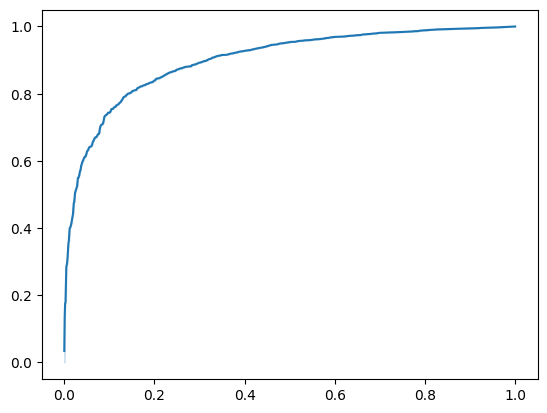

In [16]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_lr[:,0])

In [17]:
# Guardar el modelo con MLflow

model_name = f"{model_lr.__class__.__name__}"
model_lr_path = f"{MODELS_DIR}/{model_name}.pkl"

with mlflow.start_run(run_name=model_name) as run:
    metrics_lr = calculate_classification_metrics(y_real=y_test, predictions=y_pred_lr, probabilities=y_prob_lr[:,1])
    mlflow.log_metrics({
        "accuracy": metrics_lr["accuracy"],
        "precision": metrics_lr["precision"],
        "recall": metrics_lr["recall"],
        "f1_score": metrics_lr["f1_score"],
        "auc_score": metrics_lr["auc_score"]
    })

    joblib.dump(model_lr, model_lr_path)
    mlflow.log_artifact(
        model_lr_path
    )

2025/11/15 10:58:14 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/15 10:58:14 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/15 10:58:14 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025-11-15 10:58:14,864 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 10:58:14,864 - INFO - 💯🚀🎯 Modelo registrado en MLflow: precision
2025-11-15 10:58:14,865 - INFO - 💯🚀🎯 Modelo registrado en MLflow: recall
2025-11-15 10:58:14,865 - INFO - 💯🚀🎯 Modelo registrado en MLflow: f1_score
2025-11-15 10:58:14,866 - INFO - 💯🚀🎯 Modelo registrado en MLflow: auc_score
2025-11-15 10:58:14,864 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 10:58:14,864 - INFO - 💯🚀🎯 Modelo registrado en MLflow: precision
2025-11-15 10:58:14,865 - INFO - 💯🚀🎯 Modelo registrado en MLflow: recall
2025-11-15 10:58:14,865 - INFO - 💯🚀🎯 Modelo registrado en MLflow: f1_score
2025-11-15 10:58:14,866 - INFO - 

accuracy: 0.8991485126617274
precision: 0.6595365418894831
recall: 0.3391384051329056
f1_score: 0.44794188861985473
auc_score: 0.9009379374321087
🏃 View run LogisticRegression at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/f331f3711b08470d81a5322c8e13ead4
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0
🏃 View run LogisticRegression at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/f331f3711b08470d81a5322c8e13ead4
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0


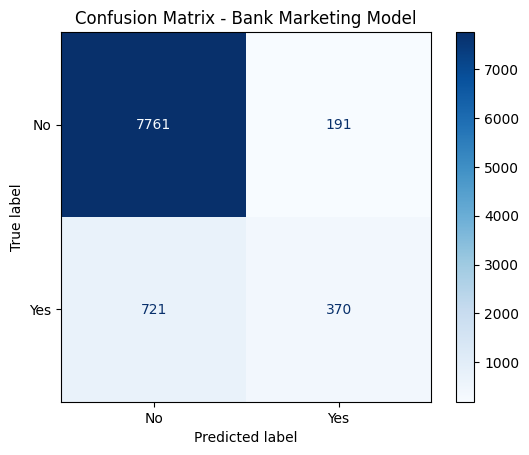

In [18]:
confusion_matrix_bank_mark(model_name, y_real=y_test, predictions=y_pred_lr)

### **Métricas Derivadas:**

| Métrica                       | Cálculo | Valor                                                            |
| ----------------------------- | ------- | ---------------------------------------------------------------- |
| **Verdaderos Negativos (TN)** | 7761    | ✅ Clientes correctamente clasificados como "No Click"            |
| **Falsos Positivos (FP)**     | 191     | ⚠️ Clientes predichos como "Click" pero NO hicieron click        |
| **Falsos Negativos (FN)**     | 721     | ❌ Clientes que SÍ hicieron click pero fueron predichos como "No" |
| **Verdaderos Positivos (TP)** | 370     | ✅ Clientes correctamente predichos como "Click"                  |

### **Indicadores de Rendimiento:**
| Indicador                 | Fórmula         | Resultado                   | Significado                                                             |
| ------------------------- | --------------- | --------------------------- | ----------------------------------------------------------------------- |
| **Accuracy**              | (TN+TP)/(Total) | (7761+370)/9043 = **89.9%** | El modelo acierta en ~9 de cada 10 predicciones                         |
| **Precision**             | TP/(TP+FP)      | 370/(370+191) = **65.9%**   | De los clientes predichos como "Click", el 66% realmente hicieron click |
| **Recall (Sensibilidad)** | TP/(TP+FN)      | 370/(370+721) = **33.9%**   | Solo detecta el 34% de los clientes que realmente harían click          |
| **Specificity**           | TN/(TN+FP)      | 7761/(7761+191) = **97.6%** | Muy bueno identificando clientes que NO van a hacer click               |

## Modelo no lineal para capturar relaciones más complejas entre las features

In [19]:
model_rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rfc.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred_rfc = model_rfc.predict(X_test_processed)

In [21]:
y_prob_rfc = model_rfc.predict_proba(X_test_processed)

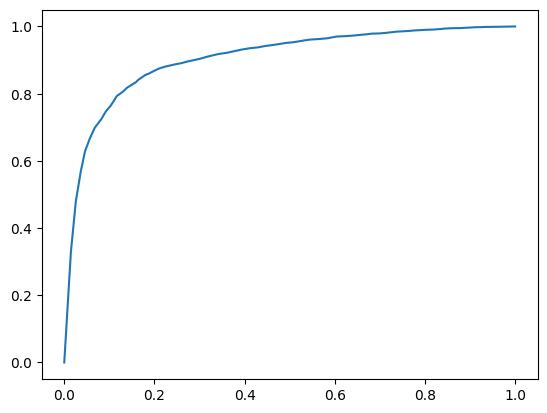

In [22]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_rfc[:,0])

In [23]:
model_name = f"{model_rfc.__class__.__name__}"
model_rfc_path = f"{MODELS_DIR}/{model_name}.pkl"

with mlflow.start_run(run_name=model_name) as run:
    metrics_rfc = calculate_classification_metrics(y_real=y_test, predictions=y_pred_rfc, probabilities=y_prob_rfc[:,1])
    
    mlflow.log_metrics({
        "accuracy": metrics_rfc["accuracy"],
        "precision": metrics_rfc["precision"],
        "recall": metrics_rfc["recall"],
        "f1_score": metrics_rfc["f1_score"],
        "auc_score": metrics_rfc["auc_score"]
    })

    joblib.dump(model_rfc, model_rfc_path)
    mlflow.log_artifact(
        model_rfc_path
    )

2025/11/15 10:58:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/15 10:58:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/15 10:58:20 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025-11-15 10:58:20,894 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 10:58:20,894 - INFO - 💯🚀🎯 Modelo registrado en MLflow: precision
2025-11-15 10:58:20,895 - INFO - 💯🚀🎯 Modelo registrado en MLflow: recall
2025-11-15 10:58:20,896 - INFO - 💯🚀🎯 Modelo registrado en MLflow: f1_score
2025-11-15 10:58:20,896 - INFO - 💯🚀🎯 Modelo registrado en MLflow: auc_score
2025-11-15 10:58:20,894 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 10:58:20,894 - INFO - 💯🚀🎯 Modelo registrado en MLflow: precision
2025-11-15 10:58:20,895 - INFO - 💯🚀🎯 Modelo registrado en MLflow: recall
2025-11-15 10:58:20,896 - INFO - 💯🚀🎯 Modelo registrado en MLflow: f1_score
2025-11-15 10:58:20,896 - INFO - 

accuracy: 0.8987061815769103
precision: 0.6593806921675774
recall: 0.3318056828597617
f1_score: 0.44146341463414634
auc_score: 0.9048386907144057
🏃 View run RandomForestClassifier at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/dbbbd8b091f54824a11fc33fe5d4d533
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0
🏃 View run RandomForestClassifier at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/dbbbd8b091f54824a11fc33fe5d4d533
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0


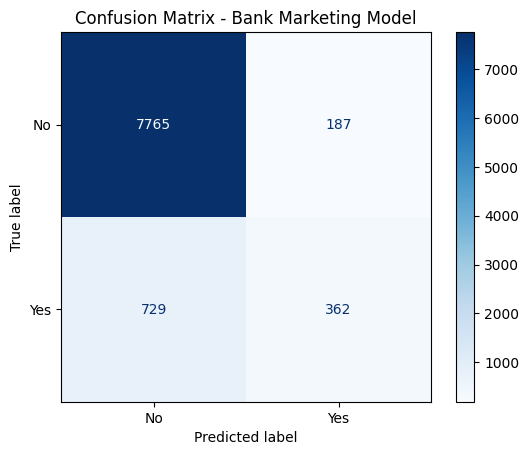

In [24]:
confusion_matrix_bank_mark(model_name, y_real=y_test, predictions=y_pred_rfc)

### **Métricas Derivadas:**

|Métrica|Valor|Interpretación|
|---|---|---|
|**Verdaderos Negativos (TN)**|7765|✅ Clientes correctamente clasificados como "No Click"|
|**Falsos Positivos (FP)**|187|⚠️ Clientes predichos como "Click" pero NO hicieron click|
|**Falsos Negativos (FN)**|729|❌ Clientes que SÍ hicieron click pero fueron predichos como "No"|
|**Verdaderos Positivos (TP)**|362|✅ Clientes correctamente predichos como "Click"|

### **Indicadores de Rendimiento:**

|Indicador|Fórmula|Resultado|Significado|
|---|---|---|---|
|**Accuracy**|(TN+TP)/(Total)|(7765+362)/9043 = **89.9%**|Prácticamente igual al LR|
|**Precision**|TP/(TP+FP)|362/(362+187) = **65.3%**|De los predichos "Click", 65% realmente hicieron click|
|**Recall**|TP/(TP+FN)|362/(362+729) = **33.2%**|Detecta el 33% de clientes que sí harían click|
|**Specificity**|TN/(TN+FP)|7765/(7765+187) = **97.6%**|Excelente identificando negativos|

## Ensamble con Boosting

In [25]:
!uv add xgboost

Resolved 171 packages in 0.59ms
Audited 167 packages in 0.05ms


In [26]:
import xgboost as xgb
from sklearn.pipeline import Pipeline

In [27]:
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model_xgb)
])

# Entrenar el modelo
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)

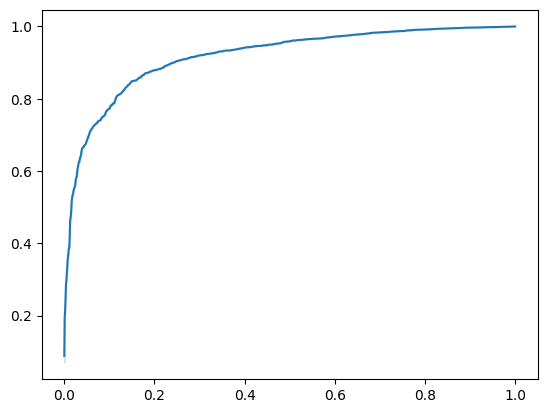

In [29]:
roc_curve_graph(y_real=y_test, probabilities=y_prob_xgb[:,0])

In [30]:
model_name = f"{pipeline_xgb.named_steps["model"].__class__.__name__}-{pipeline_xgb.named_steps["model"].get_params()["n_estimators"]}"
pipeline_path = f"{MODELS_DIR}/{model_name}_pipeline.pkl"

with mlflow.start_run(run_name=model_name) as run:
    metrics_xgb = calculate_classification_metrics(y_real=y_test, predictions=y_pred_xgb, probabilities=y_prob_xgb[:,1])

    mlflow.log_metrics({
        "accuracy": metrics_xgb["accuracy"],
        "precision": metrics_xgb["precision"],
        "recall": metrics_xgb["recall"],
        "f1_score": metrics_xgb["f1_score"],
        "auc_score": metrics_xgb["auc_score"]
    })

    joblib.dump(pipeline_xgb, pipeline_path)
    mlflow.log_artifact(
        pipeline_path
    )

2025/11/15 11:00:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/11/15 11:00:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/15 11:00:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/11/15 11:00:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2025/11/15 11:00:09 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2025-11-15 11:00:09,962 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 11:00:09,963 - INFO - 💯🚀🎯 Modelo registrado en MLflow: precision
2025-11-15 11:00:09,963 - INFO - 💯🚀🎯 Modelo registrado en MLflow: recall
2025-11-15 11:00:09,964 - INFO - 💯🚀🎯 Modelo registrado en MLflow: f1_score
2025-11-15 11:00:09,964 - INFO - 💯🚀🎯 Modelo registrado en MLflow: auc_score
2025-11-15 11:00:09,962 - INFO - 💯🚀🎯 Modelo registrado en MLflow: accuracy
2025-11-15 11:00:09,963 - INFO - 💯🚀🎯 Modelo registrado en MLflow: p

accuracy: 0.9036824062811014
precision: 0.6432291666666666
recall: 0.45279560036663613
f1_score: 0.5314685314685315
auc_score: 0.9177911188487478
🏃 View run XGBClassifier-300 at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/c981c6d57cd44812b5189839bdad85d4
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0
🏃 View run XGBClassifier-300 at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0/runs/c981c6d57cd44812b5189839bdad85d4
🧪 View experiment at: https://dagshub.com/edynsoncoronado/mle-iii.mlflow/#/experiments/0


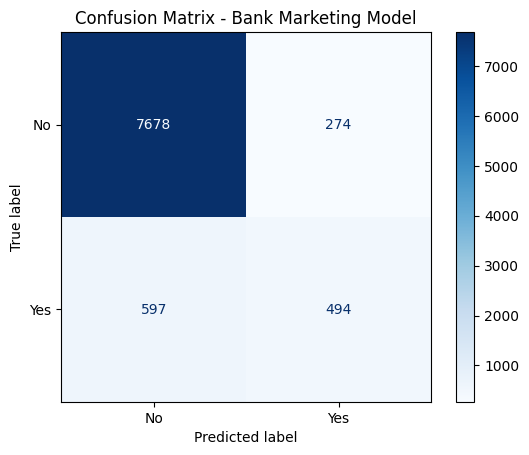

In [ ]:
confusion_matrix_bank_mark(model_name, y_real=y_test, predictions=y_pred_xgb)

### **Métricas Derivadas:**

|Métrica|Valor|Interpretación|
|---|---|---|
|**Verdaderos Negativos (TN)**|7678|✅ Clientes correctamente clasificados como "No Click"|
|**Falsos Positivos (FP)**|274|⚠️ Clientes predichos como "Click" pero NO hicieron click|
|**Falsos Negativos (FN)**|597|❌ Clientes que SÍ hicieron click pero fueron predichos como "No"|
|**Verdaderos Positivos (TP)**|494|✅ Clientes correctamente predichos como "Click"|

### **Indicadores de Rendimiento:**

| Indicador       | Fórmula         | Resultado                   | Significado                                            |
| --------------- | --------------- | --------------------------- | ------------------------------------------------------ |
| **Accuracy**    | (TN+TP)/(Total) | (7678+494)/9043 = **90.2%** | Ligeramente mejor que LR y RFC                         |
| **Precision**   | TP/(TP+FP)      | 494/(494+274) = **64.4%**   | De los predichos "Click", 64% realmente hicieron click |
| **Recall**      | TP/(TP+FN)      | 494/(494+597) = **45.3%**   | 🎯 **Detecta el 45% de clientes que sí harían click**  |
| **Specificity** | TN/(TN+FP)      | 7678/(7678+274) = **96.6%** | Muy bueno, pero un poco peor que los otros             |


# Evaluar modelos

In [ ]:
from sklearn.metrics import classification_report

print("\n📊 MÉTRICAS DEL RANDOM FOREST")
print(classification_report(y_test, y_pred_rfc))


📊 MÉTRICAS DEL RANDOM FOREST
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
print("\n📊 MÉTRICAS DE LOGISTIC REGRESSION ")
print(classification_report(y_test, y_pred_lr))


📊 MÉTRICAS DE LOGISTIC REGRESSION 
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
print("\n📊 MÉTRICAS DE XGBOOST ")
print(classification_report(y_test, y_pred_xgb))


📊 MÉTRICAS DE XGBOOST 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.64      0.45      0.53      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.71      0.74      9043
weighted avg       0.89      0.90      0.90      9043



## Cuál es el mejor modelo para Bank Marketing?

|Métrica|Logistic Regression|Random Forest|**XGBoost**|🏆 Mejor|
|---|---|---|---|---|
|**Accuracy**|89.9%|89.9%|**90.2%**|🎯 XGB|
|**Precision**|65.9%|65.3%|**64.4%**|LR|
|**Recall**|33.9%|33.2%|**45.3%**|🎯 **XGB**|
|**Specificity**|97.6%|97.6%|**96.6%**|LR/RFC|
|**Falsos Positivos**|191|187|**274**|RFC|
|**Falsos Negativos**|721|729|**597**|🎯 **XGB**|
|**Verdaderos Positivos**|370|362|**494**|🎯 **XGB**|

🎯 Si quieres MAXIMIZAR CONVERSIONES → XGBoost es el mejor
- Captura 45% de clientes interesados vs 34% con LR
- Ganas 124 clientes potenciales adicionales
- Aceptas 83 falsos positivos adicionales (costo de contacto)
- ROI probablemente mejor si el costo de contacto es bajo
